In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/Student_Feedback.csv",
    encoding="latin-1"
)

print("Original shape:", df.shape)

# Remove exact duplicate raw comments
df_model = (
    df.drop_duplicates(subset=["comments"])
      .reset_index(drop=True)
)

print("Final comparison dataset:", df_model.shape)

Original shape: (1086, 2)
Final comparison dataset: (1063, 2)


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_model["cleaned_text"] = df_model["comments"].apply(clean_text)

print(df_model.columns.tolist())
print(df_model[["comments", "cleaned_text"]].head())

['comments', 'sentiments', 'cleaned_text']
                                            comments  \
0                TEACHERS HELP US IN CAREER BUILDING   
1  Having no technical knowledge about their taug...   
2  teacher should give us the practical knowledge...   
3                        better teaching methodology   
4                               best teaching method   

                                        cleaned_text  
0                teachers help us in career building  
1  having no technical knowledge about their taug...  
2  teacher should give us the practical knowledge...  
3                        better teaching methodology  
4                               best teaching method  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(
    df_model["cleaned_text"]
)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (1063, 3000)


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

tfidf_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_tfidf)

    score = silhouette_score(
        X_tfidf,
        labels
    )

    tfidf_results.append({
        "K": k,
        "Silhouette Score": score
    })

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.0059
K = 3, Silhouette Score = 0.0089
K = 4, Silhouette Score = 0.0099
K = 5, Silhouette Score = 0.0090
K = 6, Silhouette Score = 0.0123
K = 7, Silhouette Score = 0.0129
K = 8, Silhouette Score = 0.0113


In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    df_model["comments"].tolist(),
    show_progress_bar=True
)

print("SBERT embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

SBERT embedding shape: (1063, 384)


In [15]:
sbert_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(
        embeddings,
        labels
    )

    sbert_results.append({
        "K": k,
        "Silhouette Score": score
    })

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.0807
K = 3, Silhouette Score = 0.0348
K = 4, Silhouette Score = 0.0322
K = 5, Silhouette Score = 0.0289
K = 6, Silhouette Score = 0.0347
K = 7, Silhouette Score = 0.0393
K = 8, Silhouette Score = 0.0388


In [53]:
comparison_df = pd.DataFrame({
    "K": range(2, 9),
    "TF-IDF Silhouette": [
        result["Silhouette Score"]
        for result in tfidf_results
    ],
    "SBERT Silhouette": [
        result["Silhouette Score"]
        for result in sbert_results
    ]
})

comparison_df
comparison_df.to_csv(
    "../results/tables/clustering_comparison.csv",
    index=False
)

In [17]:
best_tfidf = comparison_df.loc[
    comparison_df["TF-IDF Silhouette"].idxmax()
]

best_sbert = comparison_df.loc[
    comparison_df["SBERT Silhouette"].idxmax()
]

print(
    f"Best TF-IDF: "
    f"K={int(best_tfidf['K'])}, "
    f"Silhouette={best_tfidf['TF-IDF Silhouette']:.4f}"
)

print(
    f"Best SBERT: "
    f"K={int(best_sbert['K'])}, "
    f"Silhouette={best_sbert['SBERT Silhouette']:.4f}"
)

Best TF-IDF: K=7, Silhouette=0.0129
Best SBERT: K=2, Silhouette=0.0807


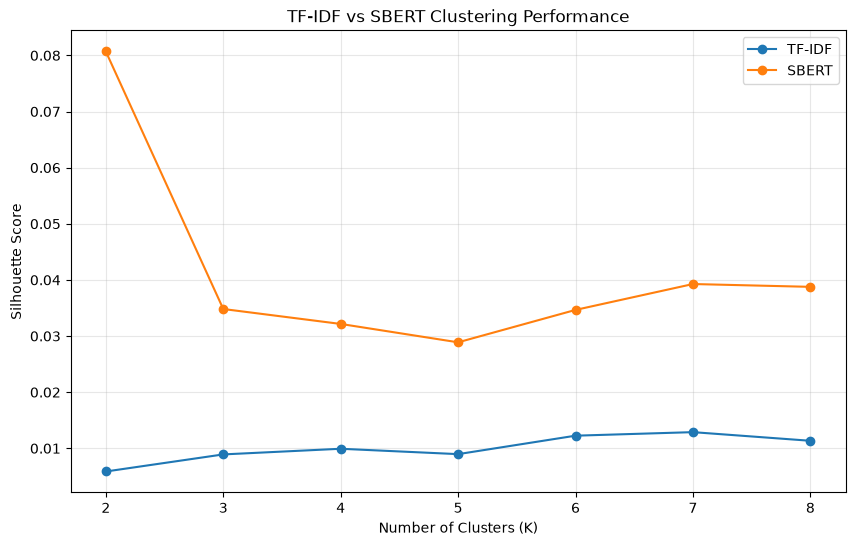

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["K"],
    comparison_df["TF-IDF Silhouette"],
    marker="o",
    label="TF-IDF"
)

plt.plot(
    comparison_df["K"],
    comparison_df["SBERT Silhouette"],
    marker="o",
    label="SBERT"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("TF-IDF vs SBERT Clustering Performance")

plt.xticks(range(2, 9))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
# Final TF-IDF clustering with best K = 7

tfidf_kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

tfidf_final_labels = tfidf_kmeans.fit_predict(X_tfidf)

df_model["tfidf_final_cluster"] = tfidf_final_labels

print(
    df_model["tfidf_final_cluster"]
    .value_counts()
    .sort_index()
)

tfidf_final_cluster
0     69
1    449
2     62
3    121
4     73
5    177
6    112
Name: count, dtype: int64


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_centroids = tfidf_kmeans.cluster_centers_

for cluster in range(7):

    cluster_indices = np.where(
        tfidf_final_labels == cluster
    )[0]

    cluster_vectors = X_tfidf[cluster_indices]

    similarities = cosine_similarity(
        cluster_vectors,
        tfidf_centroids[cluster].reshape(1, -1)
    ).flatten()

    top_indices = similarities.argsort()[-10:][::-1]

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster} | SIZE: {len(cluster_indices)}")
    print("=" * 70)

    for rank, idx in enumerate(top_indices, 1):
        original_idx = cluster_indices[idx]

        print(
            f"{rank}. "
            f"{df_model.iloc[original_idx]['comments']}"
        )


CLUSTER 0 | SIZE: 69
1. teachers do not work hard
2. teachers do not prepare lectures
3. teachers do not satisfy to our queries
4. teachers do not make the subject interesting
5. teachers do not provide marked quizes 
6. teachers do not provided marked assignments in time
7. teachers do not follow time table strictly
8. teachers do not follow time table
9. teachers do not reply properly to our questions
10. do not complete work

CLUSTER 1 | SIZE: 449
1. First of all thank you sir. whatever you taught you taught well. you worked hard for us
2. Sir, you taught us very well
3. you taught us very well
4. You taught us very well
5. you taught us something that all in the world are talking about
6. you encourage us to learnt
7. sir thank you, you teach us in a very friendly environment
8. I rate you as good teacher
9. sir you taught we in an excellent manner but we were new entrants to this field of knowledge
10. lab work is not useful to us

CLUSTER 2 | SIZE: 62
1. he is very competitive t

In [24]:
sbert_kmeans_7 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

sbert_final_labels_7 = sbert_kmeans_7.fit_predict(embeddings)

# Store cluster labels in dataframe
df_model["sbert_cluster_7"] = sbert_final_labels_7

print("SBERT K=7 cluster sizes:")
print(
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_index()
)

print(df_model.columns.tolist())
print(
    df_model[
        ["comments", "tfidf_final_cluster", "sbert_cluster_7"]
    ].head(10)
)

SBERT K=7 cluster sizes:
sbert_cluster_7
0    156
1     56
2     96
3    253
4    172
5    186
6    144
Name: count, dtype: int64
['comments', 'sentiments', 'cleaned_text', 'tfidf_final_cluster', 'sbert_cluster_7']
                                            comments  tfidf_final_cluster  \
0                TEACHERS HELP US IN CAREER BUILDING                    1   
1  Having no technical knowledge about their taug...                    1   
2  teacher should give us the practical knowledge...                    5   
3                        better teaching methodology                    4   
4                               best teaching method                    4   
5  teaching method is very tough and very diffcul...                    4   
6      THEY IMPART modern and latest knowledge to us                    6   
7  teachers give us all the required information ...                    5   
8                    Your teaching style is engaging                    4   
9          leas

In [25]:
comparison_sizes = pd.DataFrame({
    "TF-IDF": df_model["tfidf_final_cluster"].value_counts().sort_index(),
    "SBERT": df_model["sbert_cluster_7"].value_counts().sort_index()
})

print(comparison_sizes)

   TF-IDF  SBERT
0      69    156
1     449     56
2      62     96
3     121    253
4      73    172
5     177    186
6     112    144


In [26]:
cluster_comparison = pd.crosstab(
    df_model["tfidf_final_cluster"],
    df_model["sbert_cluster_7"]
)

print(cluster_comparison)

sbert_cluster_7       0   1   2   3    4   5   6
tfidf_final_cluster                             
0                     0   0   1  33    5  19  11
1                    59  53  12  73  111  65  76
2                     1   0  60   0    1   0   0
3                    23   0   1  32   32  18  15
4                    55   1   8   5    2   1   1
5                    14   1   9  89    8  39  17
6                     4   1   5  21   13  44  24


In [55]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df_model["tfidf_final_cluster"],
    df_model["sbert_cluster_7"]
)

print(f"Adjusted Rand Index: {ari:.4f}")
agreement_table = pd.DataFrame({
    "Metric": ["Adjusted Rand Index"],
    "Value": [ari]
})

agreement_table.to_csv(
    "../results/tables/model_agreement.csv",
    index=False
)

Adjusted Rand Index: 0.0710


In [28]:
for cluster_id in sorted(df_model["sbert_cluster_7"].unique()):

    cluster_data = df_model[
        df_model["sbert_cluster_7"] == cluster_id
    ]

    print("\n" + "=" * 70)
    print(f"SBERT CLUSTER {cluster_id} | SIZE: {len(cluster_data)}")
    print("=" * 70)

    for i, comment in enumerate(cluster_data["comments"].head(10), 1):
        print(f"{i}. {comment}")


SBERT CLUSTER 0 | SIZE: 156
1. teacher should give us the practical knowledge other than theortical
2. better teaching methodology
3. best teaching method
4. teaching method is very tough and very diffcult to understand
5. teachers give us all the required information to improve the performance.
6. Your teaching style is engaging
7. teacher was kind
8. FACULTY DID TREMENDOUS JOB OF TEACHING DURING COVID
9. AWESOME PERFORMANCE by the instructor
10. The counseling for the practical life and Character upbringing should also go hand in hand with course.

SBERT CLUSTER 1 | SIZE: 56
1. Practical and easy learning
2. you taught us data analysis, that was awesome
3. I have also earned as a freelancer usign jupyter notebook. It is all because of you sir, thank you
4. I will become a data analyst. It is all because of you
5. after you taught us data mining, I have chosen it as a field for my career
6. with your given guidance and with our continuous effort and hardwork we can be data scientist


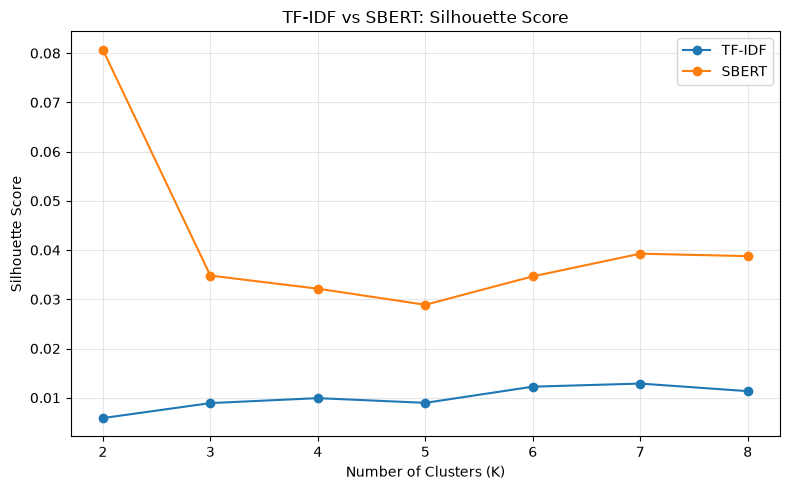

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["K"],
    comparison_df["TF-IDF Silhouette"],
    marker="o",
    label="TF-IDF"
)

plt.plot(
    comparison_df["K"],
    comparison_df["SBERT Silhouette"],
    marker="o",
    label="SBERT"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("TF-IDF vs SBERT: Silhouette Score")
plt.xticks(comparison_df["K"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/tfidf_vs_sbert_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
interpret_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000
)

X_interpret = interpret_vectorizer.fit_transform(
    df_model["cleaned_text"]
)

feature_names = interpret_vectorizer.get_feature_names_out()

print("Interpretation TF-IDF shape:", X_interpret.shape)


# ---------------------------------------------------------
# Find top terms for each SBERT cluster
# ---------------------------------------------------------

cluster_keyword_results = {}

for cluster_id in sorted(df_model["sbert_cluster_7"].unique()):

    cluster_indices = (
        df_model["sbert_cluster_7"] == cluster_id
    ).values

    # Average TF-IDF score of each term within the cluster
    cluster_scores = X_interpret[cluster_indices].mean(axis=0)

    cluster_scores = np.asarray(
        cluster_scores
    ).flatten()

    # Get indices of highest scoring terms
    top_indices = cluster_scores.argsort()[::-1][:20]

    top_terms = [
        (feature_names[i], round(cluster_scores[i], 4))
        for i in top_indices
    ]

    cluster_keyword_results[cluster_id] = top_terms


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

for cluster_id, terms in cluster_keyword_results.items():

    print("\n" + "=" * 70)
    print(f"SBERT CLUSTER {cluster_id}")
    print("=" * 70)

    for term, score in terms:
        print(f"{term:<35} → {score:.4f}")

Interpretation TF-IDF shape: (1063, 1473)

SBERT CLUSTER 0
teaching                            → 0.0957
you                                 → 0.0624
good                                → 0.0615
is                                  → 0.0497
teacher                             → 0.0426
us                                  → 0.0398
teach                               → 0.0367
taught                              → 0.0366
method                              → 0.0335
of                                  → 0.0334
methodology                         → 0.0333
the                                 → 0.0301
are                                 → 0.0292
excellent                           → 0.0285
of teaching                         → 0.0273
teaching is                         → 0.0273
very                                → 0.0267
teaching style                      → 0.0260
style                               → 0.0253
teaching method                     → 0.0250

SBERT CLUSTER 1
programming             

In [54]:
theme_sizes = (
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_index()
)

theme_table = pd.DataFrame({
    "Cluster": theme_sizes.index,
    "Size": theme_sizes.values
})

theme_table["Percentage"] = (
    theme_table["Size"] / len(df_model) * 100
).round(2)

theme_table
theme_table.to_csv(
    "../results/tables/theme_distribution.csv",
    index=False
)

In [34]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Start with sklearn's English stopwords
custom_stopwords = set(ENGLISH_STOP_WORDS)

# Add dataset-specific/common words that are not useful for theme discovery
custom_stopwords.update([
    "sir",
    "teacher",
    "teachers",
    "student",
    "students",
    "you",
    "your",
    "we",
    "us",
    "they",
    "them",
    "he",
    "his",
    "she",
    "her",
    "i",
    "me",
    "my",
    "our",
    "their",
    "very",
    "really",
    "also",
    "much",
    "good",
    "great",
    "best",
    "excellent",
])

print("Total custom stopwords:", len(custom_stopwords))

Total custom stopwords: 328


In [35]:
# Keep important negation words for interpretation
important_negations = {
    "not",
    "no",
    "nor",
    "never",
    "neither",
    "without"
}

interpret_stopwords = (
    custom_stopwords - important_negations
)

print("Interpretation stopwords:", len(interpret_stopwords))
print("Negations retained:")

for word in sorted(important_negations):
    print(word, word not in interpret_stopwords)

Interpretation stopwords: 322
Negations retained:
neither True
never True
no True
nor True
not True
without True


In [36]:
interpret_vectorizer_clean = TfidfVectorizer(
    stop_words=list(interpret_stopwords),
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000
)

X_interpret_clean = interpret_vectorizer_clean.fit_transform(
    df_model["cleaned_text"]
)

feature_names_clean = (
    interpret_vectorizer_clean.get_feature_names_out()
)

print(
    "Clean interpretation TF-IDF shape:",
    X_interpret_clean.shape
)


# ---------------------------------------------------------
# Extract top terms for every SBERT cluster
# ---------------------------------------------------------

cluster_keyword_results_clean = {}

for cluster_id in sorted(
    df_model["sbert_cluster_7"].unique()
):

    cluster_indices = (
        df_model["sbert_cluster_7"] == cluster_id
    ).values

    cluster_scores = (
        X_interpret_clean[cluster_indices]
        .mean(axis=0)
    )

    cluster_scores = np.asarray(
        cluster_scores
    ).flatten()

    top_indices = (
        cluster_scores.argsort()[::-1][:15]
    )

    top_terms = [
        (
            feature_names_clean[i],
            round(cluster_scores[i], 4)
        )
        for i in top_indices
        if cluster_scores[i] > 0
    ]

    cluster_keyword_results_clean[
        cluster_id
    ] = top_terms


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

for cluster_id, terms in cluster_keyword_results_clean.items():

    print("\n" + "=" * 70)
    print(
        f"SBERT CLUSTER {cluster_id} — CLEAN TOP TERMS"
    )
    print("=" * 70)

    for term, score in terms:
        print(
            f"{term:<35} → {score:.4f}"
        )

Clean interpretation TF-IDF shape: (1063, 684)

SBERT CLUSTER 0 — CLEAN TOP TERMS
teaching                            → 0.1503
taught                              → 0.0779
teach                               → 0.0679
method                              → 0.0491
methodology                         → 0.0481
teaching style                      → 0.0393
style                               → 0.0381
teaching methodology                → 0.0343
teaching method                     → 0.0338
way                                 → 0.0266
teaches                             → 0.0241
skills                              → 0.0223
method teaching                     → 0.0206
lot                                 → 0.0196
way teaching                        → 0.0189

SBERT CLUSTER 1 — CLEAN TOP TERMS
programming                         → 0.1526
learnt                              → 0.0947
computers                           → 0.0784
hardware                            → 0.0726
computer                    

In [37]:
final_themes = {
    0: "Teaching Methodology & Teaching Style",
    1: "Technical & Programming Learning",
    2: "Teacher Approach & Interpersonal Qualities",
    3: "Teacher Performance & Student Support",
    4: "Teacher Behaviour, Fairness & Professional Conduct",
    5: "Classroom Management & Academic Practices",
    6: "Subject Knowledge & Practical Learning"
}

theme_table = (
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_index()
    .reset_index()
)

theme_table.columns = ["Cluster", "Size"]

theme_table["Percentage"] = (
    theme_table["Size"] / len(df_model) * 100
).round(2)

theme_table["Theme"] = (
    theme_table["Cluster"]
    .map(final_themes)
)

theme_table = theme_table[
    ["Cluster", "Theme", "Size", "Percentage"]
]

theme_table

,Cluster,Theme,Size,Percentage
0,0,Teaching Methodology & Teaching Style,156,14.68
1,1,Technical & Programming Learning,56,5.27
2,2,Teacher Approach & Interpersonal Qualities,96,9.03
3,3,Teacher Performance & Student Support,253,23.80
4,4,"Teacher Behaviour, Fairness & Professional Con...",172,16.18
5,5,Classroom Management & Academic Practices,186,17.50
6,6,Subject Knowledge & Practical Learning,144,13.55


In [38]:
sentiment_theme = pd.crosstab(
    df_model["sbert_cluster_7"],
    df_model["sentiments"],
    normalize="index"
) * 100

sentiment_theme = sentiment_theme.round(2)

sentiment_theme.columns = [
    "Negative (%)",
    "Neutral (%)",
    "Positive (%)"
]

sentiment_theme

,Negative (%),Neutral (%),Positive (%)
sbert_cluster_7,,,
0,19.23,73.08,7.69
1,12.50,73.21,14.29
2,23.96,72.92,3.12
3,58.10,31.62,10.28
4,25.00,62.79,12.21
5,47.85,41.94,10.22
6,52.78,40.28,6.94


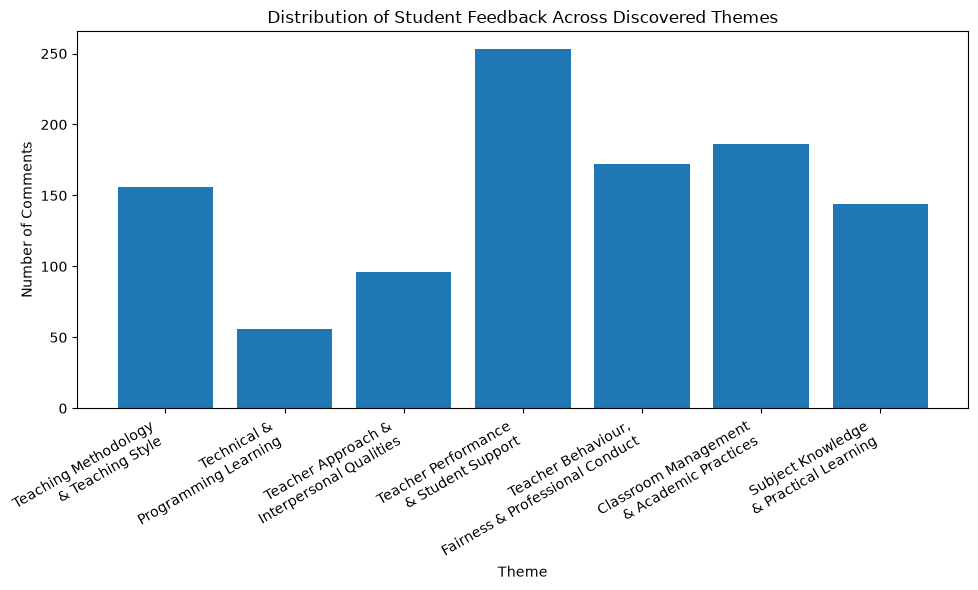

In [50]:
theme_names = {
    0: "Teaching Methodology\n& Teaching Style",
    1: "Technical &\nProgramming Learning",
    2: "Teacher Approach &\nInterpersonal Qualities",
    3: "Teacher Performance\n& Student Support",
    4: "Teacher Behaviour,\nFairness & Professional Conduct",
    5: "Classroom Management\n& Academic Practices",
    6: "Subject Knowledge\n& Practical Learning"
}

theme_counts = df_model["sbert_cluster_7"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    [theme_names[i] for i in theme_counts.index],
    theme_counts.values
)

plt.xlabel("Theme")
plt.ylabel("Number of Comments")
plt.title("Distribution of Student Feedback Across Discovered Themes")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../results/figures/theme_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

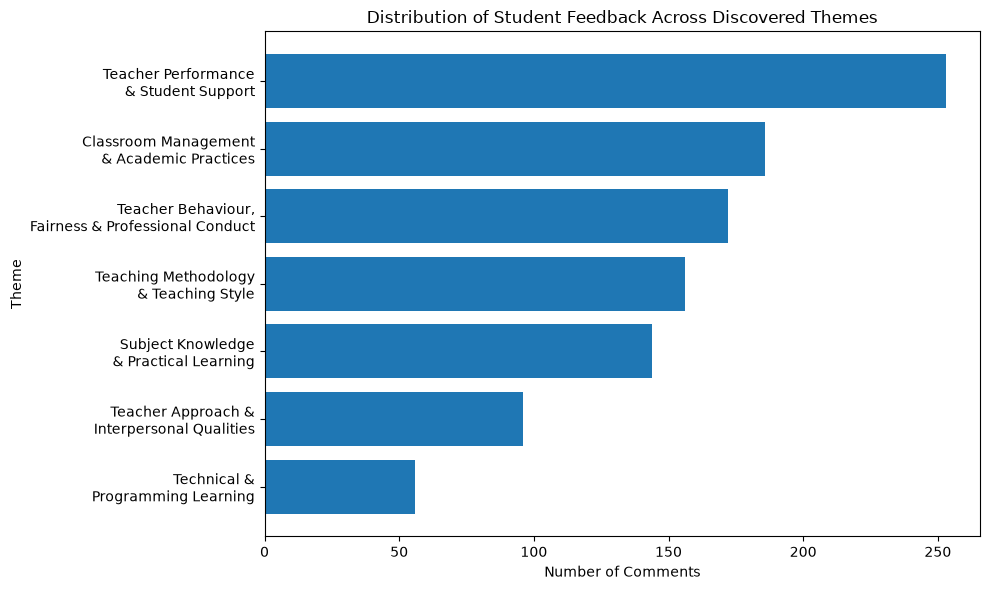

In [51]:
theme_counts = (
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_values()
)

labels = [
    theme_names[i]
    for i in theme_counts.index
]

plt.figure(figsize=(10, 6))

plt.barh(labels, theme_counts.values)

plt.xlabel("Number of Comments")
plt.ylabel("Theme")
plt.title("Distribution of Student Feedback Across Discovered Themes")

plt.tight_layout()
plt.savefig("../results/figures/sentiment_by_theme.png", dpi=300, bbox_inches="tight")
plt.show()

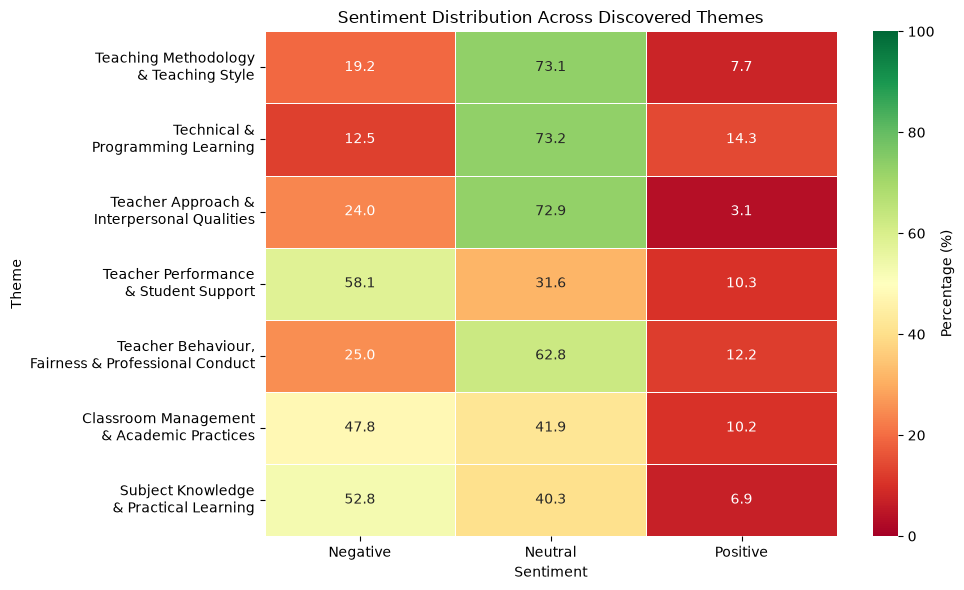

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment percentages by discovered theme
sentiment_pct = pd.crosstab(
    df_model["sbert_cluster_7"],
    df_model["sentiments"],
    normalize="index"
) * 100

# Rename sentiment columns
sentiment_pct = sentiment_pct.rename(columns={
    0: "Negative",
    1: "Neutral",
    2: "Positive"
})

# Rename clusters using your discovered themes
theme_names = {
    0: "Teaching Methodology\n& Teaching Style",
    1: "Technical &\nProgramming Learning",
    2: "Teacher Approach &\nInterpersonal Qualities",
    3: "Teacher Performance\n& Student Support",
    4: "Teacher Behaviour,\nFairness & Professional Conduct",
    5: "Classroom Management\n& Academic Practices",
    6: "Subject Knowledge\n& Practical Learning"
}

sentiment_pct.index = sentiment_pct.index.map(theme_names)

plt.figure(figsize=(10, 6))

sns.heatmap(
    sentiment_pct,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Percentage (%)"}
)

plt.title("Sentiment Distribution Across Discovered Themes")
plt.xlabel("Sentiment")
plt.ylabel("Theme")

plt.tight_layout()
plt.show()

In [42]:
themes = {
    0: "Teaching Methodology & Teaching Style",
    1: "Technical & Programming Learning",
    2: "Teacher Approach & Interpersonal Qualities",
    3: "Teacher Performance & Student Support",
    4: "Teacher Behaviour, Fairness & Professional Conduct",
    5: "Classroom Management & Academic Practices",
    6: "Subject Knowledge & Practical Learning"
}

for cluster_id, theme in themes.items():
    cluster_comments = df_model[
        df_model["sbert_cluster_7"] == cluster_id
    ]["comments"].dropna()

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id} — {theme}")
    print(f"SIZE: {len(cluster_comments)}")
    print("=" * 80)

    # Show first 5 comments
    for i, comment in enumerate(cluster_comments.head(5), 1):
        print(f"{i}. {comment}")


CLUSTER 0 — Teaching Methodology & Teaching Style
SIZE: 156
1. teacher should give us the practical knowledge other than theortical
2. better teaching methodology
3. best teaching method
4. teaching method is very tough and very diffcult to understand
5. teachers give us all the required information to improve the performance.

CLUSTER 1 — Technical & Programming Learning
SIZE: 56
1. Practical and easy learning
2. you taught us data analysis, that was awesome
3. I have also earned as a freelancer usign jupyter notebook. It is all because of you sir, thank you
4. I will become a data analyst. It is all because of you
5. after you taught us data mining, I have chosen it as a field for my career

CLUSTER 2 — Teacher Approach & Interpersonal Qualities
SIZE: 96
1. Professor should be free on his teaching styles
2. he is kind
3. one of the faculty member is weird
4. his attitude is really annoying
5. I appreciate his way of understanding students as their mindset  with physical and real lif

In [43]:
validation = {
    0: 1.0,
    1: 1.0,
    2: 0.9,
    3: 1.0,
    4: 0.8,
    5: 1.0,
    6: 1.0
}

validation_df = pd.DataFrame({
    "Cluster": list(validation.keys()),
    "Theme": [themes[i] for i in validation.keys()],
    "Manual_Theme_Fit": list(validation.values())
})

validation_df["Theme_Fit_Percentage"] = (
    validation_df["Manual_Theme_Fit"] * 100
)

validation_df

,Cluster,Theme,Manual_Theme_Fit,Theme_Fit_Percentage
0,0,Teaching Methodology & Teaching Style,1.0,100.0
1,1,Technical & Programming Learning,1.0,100.0
2,2,Teacher Approach & Interpersonal Qualities,0.9,90.0
3,3,Teacher Performance & Student Support,1.0,100.0
4,4,"Teacher Behaviour, Fairness & Professional Con...",0.8,80.0
5,5,Classroom Management & Academic Practices,1.0,100.0
6,6,Subject Knowledge & Practical Learning,1.0,100.0


In [44]:
output_cols = [
    "comments",
    "sentiments",
    "cleaned_text",
    "sbert_cluster_7"
]

final_results = df_model[output_cols].copy()

final_results.to_csv(
    "../data/processed/final_student_feedback_themes.csv",
    index=False
)

print("Saved:", final_results.shape)

Saved: (1063, 4)


In [45]:
theme_names = {
    0: "Teaching Methodology & Teaching Style",
    1: "Technical & Programming Learning",
    2: "Teacher Approach & Interpersonal Qualities",
    3: "Teacher Performance & Student Support",
    4: "Teacher Behaviour, Fairness & Professional Conduct",
    5: "Classroom Management & Academic Practices",
    6: "Subject Knowledge & Practical Learning"
}

final_results["theme"] = final_results["sbert_cluster_7"].map(theme_names)

final_results.to_csv(
    "../data/processed/final_student_feedback_themes.csv",
    index=False
)

final_results.head()

,comments,sentiments,cleaned_text,sbert_cluster_7,theme
0,TEACHERS HELP US IN CAREER BUILDING,1,teachers help us in career building,3,Teacher Performance & Student Support
1,Having no technical knowledge about their taug...,0,having no technical knowledge about their taug...,6,Subject Knowledge & Practical Learning
2,teacher should give us the practical knowledge...,2,teacher should give us the practical knowledge...,0,Teaching Methodology & Teaching Style
3,better teaching methodology,1,better teaching methodology,0,Teaching Methodology & Teaching Style
4,best teaching method,1,best teaching method,0,Teaching Methodology & Teaching Style


In [46]:
theme_summary = (
    final_results
    .groupby("theme")
    .agg(
        comments=("comments", "count")
    )
    .reset_index()
)

theme_summary["percentage"] = (
    theme_summary["comments"] / len(final_results) * 100
).round(2)

theme_summary = theme_summary.sort_values(
    "comments",
    ascending=False
)

theme_summary

,theme,comments,percentage
4,Teacher Performance & Student Support,253,23.80
0,Classroom Management & Academic Practices,186,17.50
3,"Teacher Behaviour, Fairness & Professional Con...",172,16.18
5,Teaching Methodology & Teaching Style,156,14.68
1,Subject Knowledge & Practical Learning,144,13.55
2,Teacher Approach & Interpersonal Qualities,96,9.03
6,Technical & Programming Learning,56,5.27


In [47]:
theme_summary.to_csv(
    "../data/processed/theme_summary.csv",
    index=False
)